# GCAP3226 Week 4 — In-class exercise (5%)

**Individual.** Three tasks + submit (Commit & Push → Moodle GitHub URL).

| Task | Do this |
|------|---------|
| **1** | Percentage change by A&E triage; largest fall / rise; triage 4+5 combined |
| **2** | Grouped bar chart: H1 2025 vs H1 2026 attendances by triage (10 bars) + numbers / percentage change |
| **3** | Short write-up: one supporting point + one gap for the A&E claim |


## Setup

Run the next cell. Data: `week4_ae_triage_h1.csv` (**H1** 2025 vs **H1** 2026 attendances by triage).

**H1** = first half of the year (usually **1 January – 30 June**).

**AI:** `Cmd+I` / `Ctrl+I` on a code cell → implement the comment prompt → **Keep**. Interpretations in your own words.


In [1]:
# Setup — run first
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_FILE = "week4_ae_triage_h1.csv"
path = Path(DATA_FILE) if Path(DATA_FILE).is_file() else Path.cwd() / DATA_FILE
df = pd.read_csv(path)
print("Using:", path.resolve())
df



Using: /workspaces/GCAP3226_week4/week4_ae_triage_h1.csv


,triage,triage_name,attend_h1_2025,attend_h1_2026
0,1,Critical,13848,14541
1,2,Emergency,28554,29981
2,3,Urgent,400428,411994
3,4,Semi-urgent,489032,441974
4,5,Non-urgent,18448,14758


## Task 1 — Percentage change

**Purpose:** Measure how A&E attendances changed from H1 2025 to H1 2026 for each triage group, so you can see which groups rose or fell before judging the A&E claim in Task 3.

1. Add a column `pct_change` = `(attend_h1_2026 - attend_h1_2025) / attend_h1_2025 * 100`.
2. Show the table.
3. Print the triage with the **largest fall** and the **largest rise**.
4. Compute the percentage change for triage **4+5 combined** (sum attendances first, then apply the same formula).

Then, in the next cell, write **1–2 sentences** answering:
- Did triage **1–2** (Critical / Emergency) mainly **rise or fall**?
- Did triage **4–5** (Semi-urgent / Non-urgent) mainly **rise or fall**?
- In one short phrase: what does that pattern look like for the A&E claim (lower-urgency down; critical/emergency protected)?


In [2]:
# Task 1
#
# Input: df (triage, triage_name, attend_h1_2025, attend_h1_2026)
# Process: Write Python code to add pct_change, display the table,
#          print largest fall and largest rise; also 4+5 combined percentage change
# Output: table + printed fall/rise + 4+5 combined
#
# Select the two attendance columns needed to calculate the percentage change.
old_attendances = df["attend_h1_2025"]
new_attendances = df["attend_h1_2026"]

# Calculate the percentage change from H1 2025 to H1 2026 for every triage group.
df["pct_change"] = (new_attendances - old_attendances) / old_attendances * 100

# Display the triage names, both attendance totals, and the new percentage-change column.
print(df[["triage", "triage_name", "attend_h1_2025", "attend_h1_2026", "pct_change"]].to_string(index=False, formatters={"pct_change": "{:.2f}%".format}))

# Find the row with the smallest percentage change, which represents the largest fall.
largest_fall = df.loc[df["pct_change"].idxmin()]

# Find the row with the largest percentage change, which represents the largest rise.
largest_rise = df.loc[df["pct_change"].idxmax()]

# Print the name and percentage change for the triage group with the largest fall.
print(f"Largest fall: Triage {largest_fall['triage']} ({largest_fall['triage_name']}) — {largest_fall['pct_change']:.2f}%")

# Print the name and percentage change for the triage group with the largest rise.
print(f"Largest rise: Triage {largest_rise['triage']} ({largest_rise['triage_name']}) — {largest_rise['pct_change']:.2f}%")

# Add the H1 2025 attendances for triages 4 and 5 to create their combined total.
triage_45_2025 = df.loc[df["triage"].isin([4, 5]), "attend_h1_2025"].sum()

# Add the H1 2026 attendances for triages 4 and 5 to create their combined total.
triage_45_2026 = df.loc[df["triage"].isin([4, 5]), "attend_h1_2026"].sum()

# Apply the same percentage-change formula to the combined triage 4+5 totals.
triage_45_pct_change = (triage_45_2026 - triage_45_2025) / triage_45_2025 * 100

# Print both combined totals and the combined percentage change.
print(f"Triage 4+5 combined: {triage_45_2025:,} → {triage_45_2026:,} ({triage_45_pct_change:.2f}%)")

 triage triage_name  attend_h1_2025  attend_h1_2026 pct_change
      1    Critical           13848           14541      5.00%
      2   Emergency           28554           29981      5.00%
      3      Urgent          400428          411994      2.89%
      4 Semi-urgent          489032          441974     -9.62%
      5  Non-urgent           18448           14758    -20.00%
Largest fall: Triage 5 (Non-urgent) — -20.00%
Largest rise: Triage 1 (Critical) — 5.00%
Triage 4+5 combined: 507,480 → 456,732 (-10.00%)


In [4]:
# Task 1 note
# Store the written interpretation of the percentage-change results in a multi-line string.
task1_note = """Triage 1–2 mainly rose: both Critical and Emergency attendances increased by 5.00%. Triage 4–5 mainly fell, with their combined attendances decreasing by 10.00%; this pattern is consistent with the claim that lower-urgency attendances fell while critical/emergency care was protected."""

# Display the completed interpretation below the Task 1 calculations.
print(task1_note)

Triage 1–2 mainly rose: both Critical and Emergency attendances increased by 5.00%. Triage 4–5 mainly fell, with their combined attendances decreasing by 10.00%; this pattern is consistent with the claim that lower-urgency attendances fell while critical/emergency care was protected.


## Task 2 — Visualization

**Purpose:** Turn the Task 1 table into a **grouped bar chart** that compares H1 2025 and H1 2026 attendances for each triage (5 groups, 2 bars each → 10 bars), and makes the **numbers** and **percentage change** easy to see.

In the next code cell, write your own IPO comment prompt, then use Inline Chat to implement it. Interpretations stay in your own words.


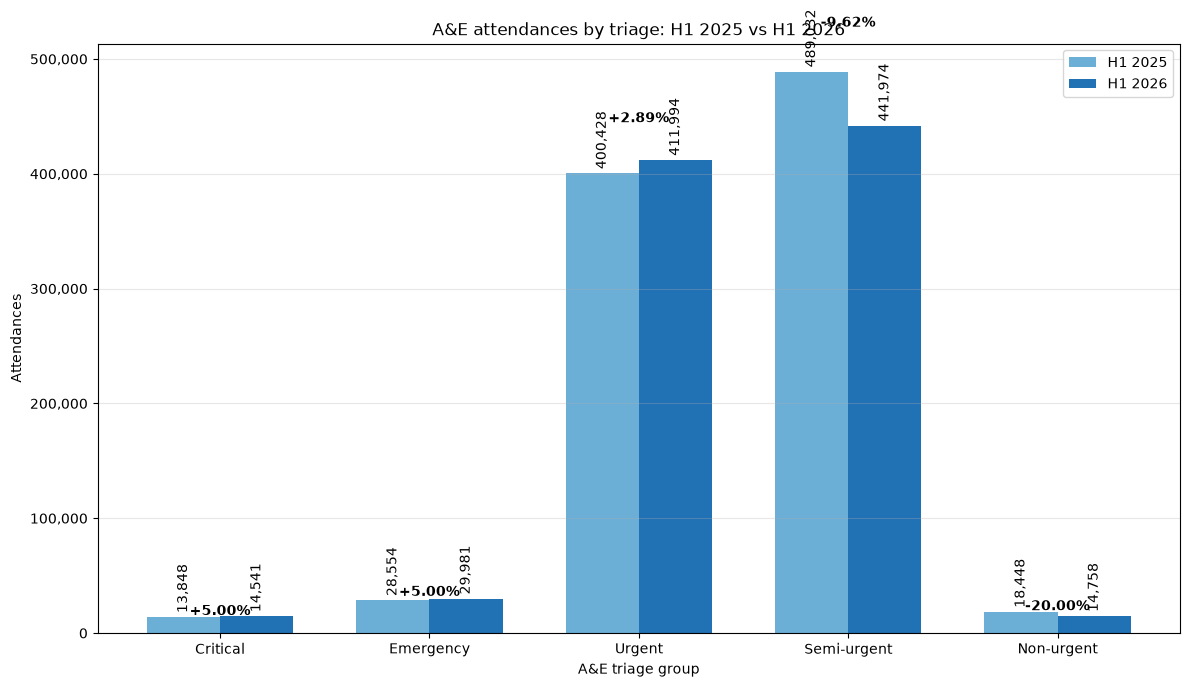

In [5]:
# Task 2 — grouped bar chart with values and percentage changes
#
# Input: df, containing triage names, H1 2025 attendances,
#        H1 2026 attendances, and the Task 1 pct_change column.
# Process: Create two bars for each triage group, label each bar with its
#          attendance number, and display the percentage change above each group.
# Output: A grouped bar chart with 5 groups and 10 bars in total.

# Store the position of each triage group on the horizontal axis.
x = range(len(df))

# Set the width of each bar so that the two bars fit beside one another.
bar_width = 0.35

# Create the chart and an axis for plotting.
fig, ax = plt.subplots(figsize=(12, 7))

# Draw the H1 2025 attendance bars slightly to the left of each group position.
bars_2025 = ax.bar(
    [position - bar_width / 2 for position in x],
    df["attend_h1_2025"],
    width=bar_width,
    label="H1 2025",
    color="#6baed6",
)

# Draw the H1 2026 attendance bars slightly to the right of each group position.
bars_2026 = ax.bar(
    [position + bar_width / 2 for position in x],
    df["attend_h1_2026"],
    width=bar_width,
    label="H1 2026",
    color="#2171b5",
)

# Add the attendance number above every bar so the exact values are visible.
ax.bar_label(bars_2025, labels=[f"{value:,}" for value in df["attend_h1_2025"]], padding=3, rotation=90)
ax.bar_label(bars_2026, labels=[f"{value:,}" for value in df["attend_h1_2026"]], padding=3, rotation=90)

# Add the percentage change above each pair of bars for easy comparison.
for position, row in zip(x, df.itertuples()):
    # Use the taller bar in the pair as the starting height for the percentage label.
    label_height = max(row.attend_h1_2025, row.attend_h1_2026)
    # Place the percentage-change label slightly above the taller bar.
    ax.text(position, label_height * 1.08, f"{row.pct_change:+.2f}%", ha="center", fontweight="bold")

# Use the triage names as the labels under each pair of bars.
ax.set_xticks(list(x), df["triage_name"])

# Label the horizontal axis with the meaning of the groups.
ax.set_xlabel("A&E triage group")

# Label the vertical axis with the measurement being plotted.
ax.set_ylabel("Attendances")

# Add a descriptive title to explain what the chart compares.
ax.set_title("A&E attendances by triage: H1 2025 vs H1 2026")

# Format the vertical-axis numbers with commas for readability.
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, position: f"{int(value):,}"))

# Add a legend so the two colours can be identified.
ax.legend()

# Add a light horizontal grid to make bar heights easier to compare.
ax.grid(axis="y", alpha=0.3)

# Prevent labels and chart elements from being cut off at the edges.
fig.tight_layout()

# Display the completed grouped bar chart.
plt.show()

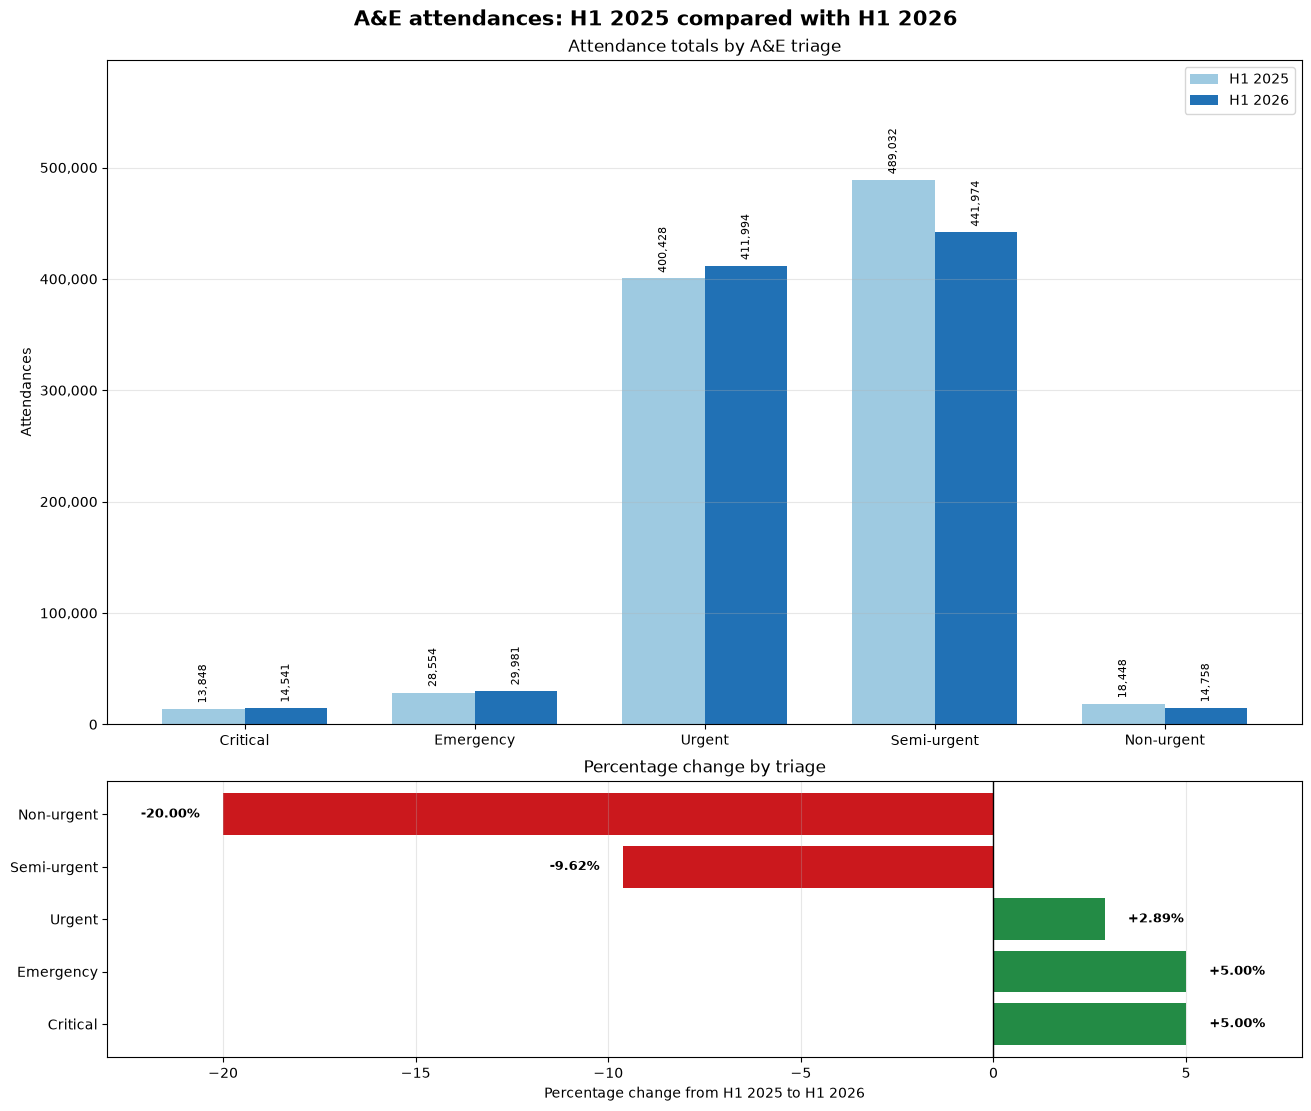

In [7]:
# Updated codes — clearer labels and a separate percentage-change panel
#
# Input: df, containing triage names, H1 2025 attendances,
#        H1 2026 attendances, and pct_change from Task 1.
# Process: Create a grouped attendance chart and a separate horizontal
#          percentage-change chart so labels do not overlap.
# Output: One figure with attendance numbers and readable percentage changes.

# Create positions for the five triage groups on the horizontal axis.
positions = list(range(len(df)))

# Set the width of each attendance bar.
bar_width = 0.36

# Create two vertically stacked charts with extra space between them.
fig, (attendance_ax, change_ax) = plt.subplots(
    2,
    1,
    figsize=(13, 11),
    gridspec_kw={"height_ratios": [2.4, 1]},
    constrained_layout=True,
)

# Create the H1 2025 bars on the left side of each triage group.
bars_2025_updated = attendance_ax.bar(
    [position - bar_width / 2 for position in positions],
    df["attend_h1_2025"],
    width=bar_width,
    label="H1 2025",
    color="#9ecae1",
)

# Create the H1 2026 bars on the right side of each triage group.
bars_2026_updated = attendance_ax.bar(
    [position + bar_width / 2 for position in positions],
    df["attend_h1_2026"],
    width=bar_width,
    label="H1 2026",
    color="#2171b5",
)

# Convert each 2025 attendance value into a comma-formatted label.
labels_2025 = [f"{value:,}" for value in df["attend_h1_2025"]]

# Convert each 2026 attendance value into a comma-formatted label.
labels_2026 = [f"{value:,}" for value in df["attend_h1_2026"]]

# Place the 2025 attendance labels vertically above their bars.
attendance_ax.bar_label(
    bars_2025_updated,
    labels=labels_2025,
    padding=4,
    rotation=90,
    fontsize=8,
)

# Place the 2026 attendance labels vertically above their bars.
attendance_ax.bar_label(
    bars_2026_updated,
    labels=labels_2026,
    padding=4,
    rotation=90,
    fontsize=8,
)

# Leave extra space above the tallest bar so labels do not touch the title.
attendance_ax.set_ylim(0, df[["attend_h1_2025", "attend_h1_2026"]].to_numpy().max() * 1.22)

# Use the triage names below each pair of attendance bars.
attendance_ax.set_xticks(positions, df["triage_name"])

# Label the attendance chart's vertical axis.
attendance_ax.set_ylabel("Attendances")

# Add a specific title to the attendance chart.
attendance_ax.set_title("Attendance totals by A&E triage")

# Format attendance-axis tick labels with commas.
attendance_ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, position: f"{int(value):,}")
)

# Add a light horizontal grid behind the attendance bars.
attendance_ax.grid(axis="y", alpha=0.3)

# Show which colour represents each year.
attendance_ax.legend(loc="upper right")

# Draw horizontal bars for percentage changes so positive and negative values are easy to compare.
change_bars = change_ax.barh(
    df["triage_name"],
    df["pct_change"],
    color=["#238b45" if value >= 0 else "#cb181d" for value in df["pct_change"]],
)

# Draw a vertical zero line to show whether each change is a rise or a fall.
change_ax.axvline(0, color="black", linewidth=1)

# Add each percentage value at the appropriate end of its horizontal bar.
for bar, change in zip(change_bars, df["pct_change"]):
    # Put positive labels just to the right of positive bars.
    label_x = change + 0.6 if change >= 0 else change - 0.6
    # Align the label so it stays outside the bar without overlapping another label.
    label_alignment = "left" if change >= 0 else "right"
    # Write the signed percentage with two decimal places.
    change_ax.text(
        label_x,
        bar.get_y() + bar.get_height() / 2,
        f"{change:+.2f}%",
        va="center",
        ha=label_alignment,
        fontsize=9,
        fontweight="bold",
    )

# Use a fixed range that includes zero and leaves room for percentage labels.
change_ax.set_xlim(-23, 8)

# Label the percentage-change axis.
change_ax.set_xlabel("Percentage change from H1 2025 to H1 2026")

# Add a title that explains the second panel.
change_ax.set_title("Percentage change by triage")

# Add a light vertical grid to make percentage differences easier to read.
change_ax.grid(axis="x", alpha=0.3)

# Add one overall caption without placing it on top of chart labels.
fig.suptitle(
    "A&E attendances: H1 2025 compared with H1 2026",
    fontsize=15,
    fontweight="bold",
)

# Display the revised figure.
plt.show()

## Task 3 — Write-up

**Claim:** After fee reform, A&E improved — lower-urgency attendances fell; critical/emergency care stayed protected; urgent care became more efficient.

You may also cite: triage III within 30 min **81.4 → 88.5** (percentage); mean wait **23 → 20** min.

**3a** — Write **one supporting point** (cite a number) and **one gap** in the evidence.

**3b** — 2–4 sentences: how well is the claim supported by the published evidence (your table / chart, and any figures cited above)?


In [8]:
# Task 3
#
# 3a asks for one numerical point supporting the claim and one limitation.
task3a = """
3a SUPPORT (1 point, cite a number):
The lower-urgency pattern supports the claim: combined triage 4+5 attendances
fell by 10.00%, from 507,480 in H1 2025 to 456,732 in H1 2026, while
Critical and Emergency attendances each rose by 5.00%.

3a GAP (1 point):
The evidence does not prove that the fee reform caused these changes because
it compares only two half-years and does not provide a control group, longer
trend data, or information about other factors that may have affected A&E use.
"""

# 3b gives an overall judgement using the attendance and waiting-time evidence.
task3b = """
3b:
The evidence fairly strongly supports the descriptive part of the claim:
lower-urgency attendances fell, while Critical and Emergency attendances were
protected and slightly increased. The reported triage III result also improved
from 81.4% to 88.5% within 30 minutes, and mean wait fell from 23 to 20 minutes,
which is consistent with improved efficiency. However, the evidence shows an
association rather than proving that the fee reform itself caused the improvement.
"""

# Print the completed answers so they appear in the notebook output.
print(task3a)
print("---")
print(task3b)


3a SUPPORT (1 point, cite a number):
The lower-urgency pattern supports the claim: combined triage 4+5 attendances
fell by 10.00%, from 507,480 in H1 2025 to 456,732 in H1 2026, while
Critical and Emergency attendances each rose by 5.00%.

3a GAP (1 point):
The evidence does not prove that the fee reform caused these changes because
it compares only two half-years and does not provide a control group, longer
trend data, or information about other factors that may have affected A&E use.

---

3b:
The evidence fairly strongly supports the descriptive part of the claim:
lower-urgency attendances fell, while Critical and Emergency attendances were
protected and slightly increased. The reported triage III result also improved
from 81.4% to 88.5% within 30 minutes, and mean wait fell from 23 to 20 minutes,
which is consistent with improved efficiency. However, the evidence shows an
association rather than proving that the fee reform itself caused the improvement.



## Submit

1. Save → Source Control → **Commit & Push**  
2. Moodle: paste your **GitHub URL**
